# INFORM localization test — histological median nerve

Notebook pulito per il caso realistico/istologico, derivato da `MEDIAN_4_localization_loop.ipynb`.

Differenze principali rispetto al caso circolare:

- usa cartelle `block_<ID>_segment_<ID>_nerve_morphology_<ID>`;
- il file true è `experiment_trial_<trial>.pkl`, non `experiment_pop_<id>...`;
- `max_stim = 1000`;
- `batch_size = 20`;
- `std_lims = (0.05, 0.2)`;
- `nerve_radius = 3`;
- ricostruisce una popolazione `fiber_population_ref` con `central_node_z="random"` e `cc=True`;
- localizza solo i primi `N_CLUSTERS_TO_LOCALIZE = 2` cluster, come nel notebook originale.

Assume che INFORM sia installato con:

```bash
pip install -e .
```


## 1. Imports

In [1]:
from pathlib import Path
import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.gaussian_process.kernels import Matern
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

from nerve_model.experiment import Experiment
from nerve_model.fiber_population import MotorFiberPopulation

from localization.candidate_generation import create_loc_candidates
from localization.bayesian_localization import performLocalizationCluster
from localization.visualization import (
    plot_recruitment_extended,
    plot_recruitment_superposed,
)

# ------------------------------------------------------------------
# Backward compatibility for legacy pickle files
# ------------------------------------------------------------------

import nerve_model.experiment as experiment
import nerve_model.fiber_population as fiber_population
import nerve_model.nerve_section as nerve_section
import nerve_model.histological_nerve_section as nerve_section_2
import nerve_model.recruitment_curves as recruitment_curves
import nerve_model.implant as implant

sys.modules["experiment"] = experiment
sys.modules["fiber_population"] = fiber_population
sys.modules["nerve_section"] = nerve_section
sys.modules["nerve_section_2"] = nerve_section_2
sys.modules["recruitment_curves"] = recruitment_curves
sys.modules["implant"] = implant
# ------------------------------------------------------------------

np.set_printoptions(suppress=True)

print("Imports OK")

Imports OK


## 2. Parameters

In [32]:
# Root folder containing "Median nerve/experiments" and "Median nerve/surrogate_experiments"
PROJECT_FOLDER = Path(r"C:/Users/laura/OneDrive/Desktop/Projects/Models")

# Histological median nerve identifiers
BLOCK_ID = 10
SEGMENT_ID = 1
MASK_ID = 1
SHIFT = ""

TRIAL = "cross"

# Recruitment curve parameters
N_STIMS_PER_SITE = 20
MIN_STIM = 0
MAX_STIM = 1

# Bayesian localization parameters
MAX_ITER = 20
BATCH_SIZE = 20
TRADEOFF = 0.1

# Candidate grid parameters for histological median nerve
STD_LIMS = (0.05, 0.2)
NUM_LIMS = (200, 200)
N_TRIES_LOCS = (20, 20)
N_TRIES_STD = 20
N_TRIES_NUM = 20
NERVE_RADIUS = 3

# Original MEDIAN notebook localizes only the first two clusters
N_CLUSTERS_TO_LOCALIZE = 2

# Save options
SAVE_RESULTS = True
SAVE_FULL_REFERENCE_OBJECTS = False  # safer: avoids pickle issues with nested RecruitmentCurves objects

COLOR_LIST = [
    "#a6cee3",
    "#1f78b4",
    "#b2df8a",
    "#33a02c",
    "#fb9a99",
    "#e31a1c",
    "#fdbf6f",
    "#ff7f00",
    "#cab2d6",
    "#6a3d9a",
    "#ffff99",
    "#b15928",
]

print("Parameters set")

Parameters set


## 3. Paths

In [33]:
nerve_folder = f"block_{BLOCK_ID}_segment_{SEGMENT_ID}_nerve_morphology_{MASK_ID}"
inferred_nerve_folder = f"{nerve_folder}{SHIFT}"

inferred_base_path = (
    PROJECT_FOLDER
    / "Median nerve"
    / "surrogate_experiments"
    / inferred_nerve_folder
    / TRIAL
)

true_base_path = (
    PROJECT_FOLDER
    / "Median nerve"
    / "experiments"
    / nerve_folder
    / TRIAL
)

inferred_experiment_path = inferred_base_path / f"experiment_trial_{TRIAL}.pkl"
true_experiment_path = true_base_path / f"experiment_trial_{TRIAL}.pkl"

results_folder = inferred_base_path / "results"
results_folder.mkdir(parents=True, exist_ok=True)

results_filename = f"results_{TRIAL}_with_topography.pkl"

print("Inferred experiment:", inferred_experiment_path)
print("True experiment:", true_experiment_path)
print("Results folder:", results_folder)

assert inferred_experiment_path.exists(), f"Missing file: {inferred_experiment_path}"
assert true_experiment_path.exists(), f"Missing file: {true_experiment_path}"

print("Paths OK")

Inferred experiment: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\surrogate_experiments\block_10_segment_1_nerve_morphology_1\cross\experiment_trial_cross.pkl
True experiment: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\experiments\block_10_segment_1_nerve_morphology_1\cross\experiment_trial_cross.pkl
Results folder: C:\Users\laura\OneDrive\Desktop\Projects\Models\Median nerve\surrogate_experiments\block_10_segment_1_nerve_morphology_1\cross\results
Paths OK


## 4. Load experiments

In [34]:
with open(inferred_experiment_path, "rb") as f:
    full_inferred_experiment = pickle.load(f)

with open(true_experiment_path, "rb") as f:
    true_experiment = pickle.load(f)

print("Full inferred experiment:")
print(full_inferred_experiment)

print("\nTrue experiment:")
print(true_experiment)

Full inferred experiment:
Experiment(n_fibers=6800, n_sites=8, lead_field_matrix_loaded=True, activation_predictor_loaded=True)

True experiment:
Experiment(n_fibers=2400, n_sites=8, lead_field_matrix_loaded=True, activation_predictor_loaded=True)


## 5. Build reference fiber population for histological case

In [35]:
# The original MEDIAN notebook reconstructs the true population with:
# central_node_z="random" and cc=True.
CC = True

fiber_population_ref = MotorFiberPopulation(
    n_internodes=true_experiment.fiber_population.n_internodes,
    diameters=true_experiment.fiber_population.diameters,
    locs=true_experiment.fiber_population.locs,
    central_node_z="random",
    cluster_ids=true_experiment.fiber_population.cluster_ids,
    nerve_topography=true_experiment.nerve_topography,
    cc=CC,
)

n_clusters = fiber_population_ref.n_groups
mean_locs_x = fiber_population_ref.cluster_locs[:, 0]
mean_locs_y = fiber_population_ref.cluster_locs[:, 1]
new_std = fiber_population_ref.cluster_std

print("Total clusters:", n_clusters_total)
print("Clusters to localize:", n_clusters)
print("Reference cluster locations shape:", fiber_population_ref.cluster_locs.shape)

  0%|          | 0/2400 [00:00<?, ?it/s]

Total clusters: 12
Clusters to localize: 12
Reference cluster locations shape: (12, 2)


## 6. Plot true and inferred nerve sections

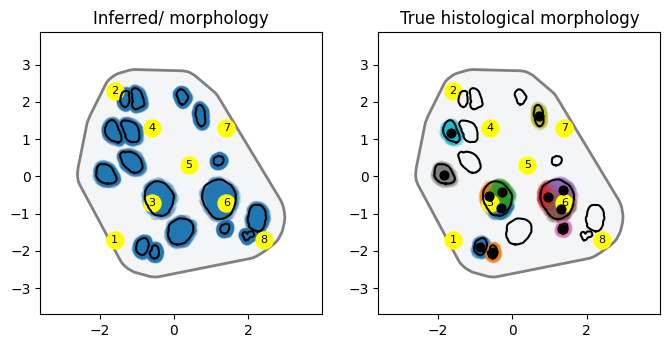

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

full_inferred_experiment.nerve_topography.plot(ax=ax[0])
full_inferred_experiment.fiber_population.plot(ax=ax[0])
full_inferred_experiment.implant.plot(ax=ax[0])
full_inferred_experiment.implant.plot_text(ax=ax[0])
ax[0].set_title("Inferred/ morphology")
ax[0].set_aspect("equal")

true_experiment.nerve_topography.plot(ax=ax[1])
true_experiment.fiber_population.plot(ax=ax[1])
true_experiment.implant.plot(ax=ax[1])
true_experiment.implant.plot_text(ax=ax[1])
ax[1].scatter(mean_locs_x[:n_clusters], mean_locs_y[:n_clusters], c="black", s=40)
ax[1].set_title("True histological morphology")
ax[1].set_aspect("equal")

plt.show()

## 7. Compute reference recruitment curves

True recruitment curves shape: (8, 12, 20)
Amplitudes: [0.         0.05263158 0.10526316] ... [0.89473684 0.94736842 1.        ]


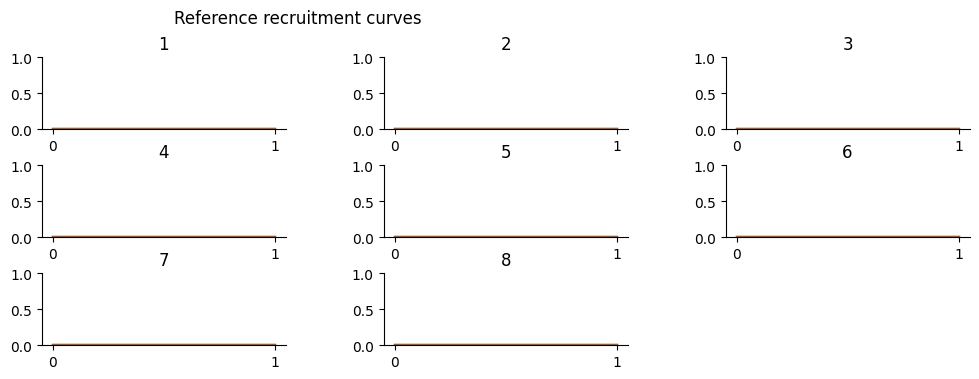

In [37]:
amp_lims = [MIN_STIM, MAX_STIM]

true_recruitment_curves_obj = true_experiment.generate_recruitment_curves(
    amp_lims=amp_lims,
    n_steps=N_STIMS_PER_SITE,
    method="from_self",
)

n_sites = true_recruitment_curves_obj.n_sites
amplitudes = true_recruitment_curves_obj.amplitudes
true_recruitment_curves = true_recruitment_curves_obj.recruitment_values

print("True recruitment curves shape:", true_recruitment_curves.shape)
print("Amplitudes:", amplitudes[:3], "...", amplitudes[-3:])

fig, _ = plot_recruitment_extended(
    true_recruitment_curves=true_recruitment_curves,
    n_clusters=n_clusters,
    amplitudes=amplitudes,
    n_sites=n_sites,
    colorList=COLOR_LIST,
    title="Reference recruitment curves",
)
plt.show()

## 8. Create localization candidates

In [38]:
candidates_grid = create_loc_candidates(
    nerve_radius=NERVE_RADIUS,
    limCandidateStd=STD_LIMS,
    limCandidateNum=NUM_LIMS,
    nTriesLocs=N_TRIES_LOCS,
    nTriesStd=N_TRIES_STD,
    nTriesNum=N_TRIES_NUM,
)

scaler = StandardScaler()
standardized_candidates_grid = scaler.fit_transform(candidates_grid)

print("Candidate grid shape:", candidates_grid.shape)
print("Standardized candidate grid shape:", standardized_candidates_grid.shape)
print(candidates_grid[:5])

Candidate grid shape: (110400, 4)
Standardized candidate grid shape: (110400, 4)
[[ -1.10526316  -2.68421053   0.05       200.        ]
 [ -1.10526316  -2.68421053   0.05       200.        ]
 [ -1.10526316  -2.68421053   0.05       200.        ]
 [ -1.10526316  -2.68421053   0.05       200.        ]
 [ -1.10526316  -2.68421053   0.05       200.        ]]


## 9. Run Bayesian localization

In [39]:
experiment_info = {
    "full_experiment": full_inferred_experiment,
    "full_lfm": full_inferred_experiment.lead_field_matrix,
    "amp_lims": np.array(amp_lims),
    "n_stims_per_site": N_STIMS_PER_SITE,
}

kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0],
    nu=2.5,
    length_scale_bounds=(1e-5, 1e5),
)

X_clust = [None for _ in range(n_clusters)]
Y_clust = [None for _ in range(n_clusters)]
rc_clust = [None for _ in range(n_clusters)]
X_max_clust = [None for _ in range(n_clusters)]
Y_max_clust = [None for _ in range(n_clusters)]
acq_clust = [None for _ in range(n_clusters)]
YPrior = [None for _ in range(n_clusters)]

priorX = []
priorRC = []
priorExp = []

start = time.time()

for clust in tqdm(range(n_clusters), desc="Localizing clusters"):
    refCurves = true_recruitment_curves[:, clust:clust + 1, :]

    if clust == 0:
        priorInfoX = None
        rcPrior = None
    else:
        priorX = priorX + X_clust[clust - 1]
        priorRC = priorRC + rc_clust[clust - 1]
        priorInfoX = priorX
        rcPrior = priorRC

    (
        X_clust[clust],
        Y_clust[clust],
        rc_clust[clust],
        X_max_clust[clust],
        Y_max_clust[clust],
        acq_clust[clust],
        YPrior[clust],
    ) = performLocalizationCluster(
        experiment_info=experiment_info,
        refCurves=refCurves,
        candidatesGrid=candidates_grid,
        candidatesGridStandardized=standardized_candidates_grid,
        kernel=kernel,
        tr=TRADEOFF,
        maxIter=MAX_ITER,
        batchSize=BATCH_SIZE,
        priorInfoX=priorInfoX,
        rcPrior=rcPrior,
    )

end = time.time()
print(f"Elapsed time: {end - start:.2f} s")

Localizing clusters:   0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


KeyboardInterrupt



## 10. Extract inferred parameters and errors

In [25]:
x_inferred = [None for _ in range(n_clusters)]
y_inferred = [None for _ in range(n_clusters)]
std_inferred = [None for _ in range(n_clusters)]
num_inferred = [None for _ in range(n_clusters)]

dist_error = [None for _ in range(n_clusters)]
std_error = [None for _ in range(n_clusters)]
num_error = [None for _ in range(n_clusters)]
dist_error_corrected = [None for _ in range(n_clusters)]
std_error_corrected = [None for _ in range(n_clusters)]

for i in range(n_clusters):
    x_ref = fiber_population_ref.cluster_locs[i][0]
    y_ref = fiber_population_ref.cluster_locs[i][1]
    std_ref = fiber_population_ref.cluster_std[i]
    num_ref = NUM_LIMS[0] 

    x_ref_corrected = mean_locs_x[i]
    y_ref_corrected = mean_locs_y[i]
    std_ref_corrected = new_std[i]

    best_candidate_std = X_max_clust[i][-1].reshape(1, -1)
    best_candidate = scaler.inverse_transform(best_candidate_std)[0]

    x_inferred[i] = best_candidate[0]
    y_inferred[i] = best_candidate[1]
    std_inferred[i] = best_candidate[2]
    num_inferred[i] = best_candidate[3]

    dist_error[i] = np.sqrt((x_ref - x_inferred[i]) ** 2 + (y_ref - y_inferred[i]) ** 2)
    std_error[i] = abs(std_ref - std_inferred[i]) / std_ref
    num_error[i] = abs(num_ref - num_inferred[i]) / num_ref
    dist_error_corrected[i] = np.sqrt(
        (x_ref_corrected - x_inferred[i]) ** 2
        + (y_ref_corrected - y_inferred[i]) ** 2
    )
    std_error_corrected[i] = abs(std_ref_corrected - std_inferred[i]) / std_ref_corrected

cluster_locs_inferred = np.column_stack((x_inferred, y_inferred))
cluster_std_inferred = np.asarray(std_inferred)
cluster_num_inferred = np.asarray(num_inferred)

print("Inferred cluster locations:")
print(cluster_locs_inferred)

print("\nInferred std:")
print(cluster_std_inferred)

print("\nInferred n fibers:")
print(cluster_num_inferred)

print("\nDistance error:")
print(dist_error)

print("\nCorrected distance error:")
print(dist_error_corrected)

Inferred cluster locations:
[[-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]
 [-1.10526316 -1.73684211]]

Inferred std:
[0.11315789 0.11315789 0.11315789 0.11315789 0.11315789 0.11315789
 0.11315789 0.11315789 0.11315789 0.11315789 0.11315789 0.11315789]

Inferred n fibers:
[200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.]

Distance error:
[1.1948917271094521, 1.3004637791009497, 1.5633007500473326, 2.386417306053311, 2.8325482534628343, 2.5755878670858365, 2.493613043740543, 1.926748962786197, 3.8269271269630756, 2.9599819052690606, 0.29709395694090923, 0.6624448571976216]

Corrected distance error:
[1.1948917271094521, 1.3004637791009497, 1.5633007500473326, 2.386417306053311, 2.8325482534628343, 2.5755878670858365, 2.4936130437

## 11. Build inferred experiment

In [26]:
inferred_population, inferred_identities = MotorFiberPopulation.from_existing_population(
    cluster_locs=cluster_locs_inferred,
    cluster_std=cluster_std_inferred,
    cluster_num=cluster_num_inferred.astype(int),
    fiber_population=full_inferred_experiment.fiber_population,
)

inferred_identities = inferred_identities.astype(int)

inferred_experiment = Experiment(
    fiber_population=inferred_population,
    nerve_topography=full_inferred_experiment.nerve_topography,
    implant=full_inferred_experiment.implant,
)

inferred_experiment._activation_predictor = full_inferred_experiment.activation_predictor

inferred_lfm = inferred_experiment.load_lead_field_matrix(
    full_experiment=full_inferred_experiment,
    lead_field_matrix=full_inferred_experiment.lead_field_matrix,
    identities=inferred_identities,
    save_to_hdf5=False,
)

inferred_recruitment_curves_obj = inferred_experiment.generate_recruitment_curves(
    amp_lims=np.array(amp_lims),
    n_steps=N_STIMS_PER_SITE,
    method="from_self",
)

print("Inferred recruitment curves shape:", inferred_recruitment_curves_obj.recruitment_values.shape)

  0%|          | 0/2400 [00:00<?, ?it/s]

Inferred recruitment curves shape: (8, 12, 20)


## 12. Plot final results

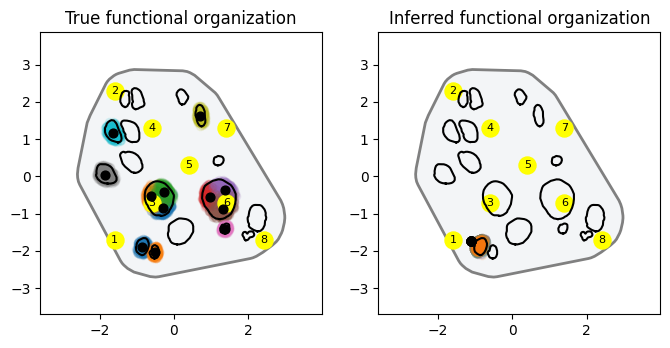

C:\Users\laura\OneDrive\Documenti\GitHub\INFORM\localization\visualization.py:119: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


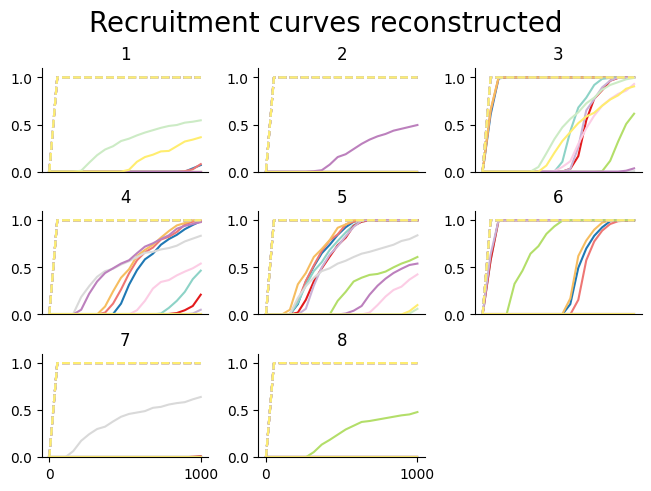

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

true_experiment.nerve_topography.plot(ax=ax[0])
true_experiment.fiber_population.plot(ax=ax[0])
true_experiment.implant.plot(ax=ax[0])
true_experiment.implant.plot_text(ax=ax[0])
ax[0].scatter(mean_locs_x[:n_clusters], mean_locs_y[:n_clusters], c="black", s=40)
ax[0].set_title("True functional organization")
ax[0].set_aspect("equal")

inferred_experiment.nerve_topography.plot(ax=ax[1])
inferred_experiment.fiber_population.plot(ax=ax[1])
inferred_experiment.implant.plot(ax=ax[1])
inferred_experiment.implant.plot_text(ax=ax[1])
ax[1].scatter(cluster_locs_inferred[:, 0], cluster_locs_inferred[:, 1], c="black", s=40)
ax[1].set_title("Inferred functional organization")
ax[1].set_aspect("equal")

plt.show()

fig, _ = plot_recruitment_superposed(
    true_recruitment_curves=true_recruitment_curves,
    inferred_recruitment_curves=inferred_recruitment_curves_obj.recruitment_values,
    amplitudes=np.linspace(MIN_STIM, MAX_STIM, N_STIMS_PER_SITE),
    n_sites=true_recruitment_curves.shape[0],
    n_clusters=n_clusters,
    title="Recruitment curves reconstructed",
)
plt.show()

In [30]:
np.max(inferred_experiment.lead_field_matrix[:,0])

212.39524394174614

In [31]:
np.max(true_experiment.lead_field_matrix[:,0])

0.20644523072703028

## 13. Save results

In [ ]:
if SAVE_RESULTS:
    save_file_name = results_folder / results_filename
    results_to_save = [
        mean_locs_x,
        mean_locs_y,
        new_std,
        true_recruitment_curves,
        MAX_STIM,
        N_STIMS_PER_SITE,
        standardized_candidates_grid,
        scaler,
        candidates_grid,
        X_clust,
        Y_clust,
        X_max_clust,
        Y_max_clust,
        acq_clust,
        YPrior,
        priorX,
        priorExp,
        inferred_experiment,
        inferred_recruitment_curves_obj,
        inferred_identities,
    ]

    with open(save_file_name, "wb") as f:
        pickle.dump(results_to_save, f)

    print("Saved:", save_file_name)
else:
    print("SAVE_RESULTS is False; nothing saved.")